# Trade SHAP Diagnostics: Model-to-Trading Feedback
**Docker image**: `ml4t-gpu`

**Purpose**: Demonstrate the `TradeShapAnalyzer` workflow that converts post-hoc
trade failures into actionable model-improvement hypotheses by clustering SHAP
decompositions of the worst trades.

**Learning objectives**:
1. Build trade records and aligned SHAP explanations from a fitted model.
2. Run `TradeShapAnalyzer.explain_worst_trades()` end-to-end.
3. Read clustered error patterns and the hypotheses the library generates.
4. Connect SHAP-driven diagnosis to feature-engineering or regime decisions.

**Book reference**: §19.5 (Trade-Level SHAP as Diagnostic Tool).

**Prerequisites**: Familiarity with SHAP values (Lundberg & Lee 2017), gradient
boosting on cross-sectional features, and the ML4T trade-record contract
(`ml4t.diagnostic.integration.backtest_contract.TradeRecord`).

**Data**: Real SPY daily OHLCV (`load_etfs`) joined with a fixed local FRED
snapshot (`load_macro`: 10Y-2Y yield slope and VIX-derived volatility regime).
Predictors are lagged one trading session before forecasting the next-session
SPY return. The macro snapshot is finalized rather than point-in-time vintage
data, so this is a diagnostic teaching example, not an unbiased macro backtest.

## Setup

In [1]:
"""Connect trade outcomes to their decision-time SHAP explanations."""

import lightgbm as lgb
import numpy as np
import pandas as pd
import plotly.express as px
import polars as pl
import shap
from IPython.display import Markdown, display
from ml4t.diagnostic.config import TradeConfig
from ml4t.diagnostic.config.trade_analysis_config import ExtractionSettings
from ml4t.diagnostic.evaluation import TradeAnalysis, TradeShapAnalyzer
from ml4t.diagnostic.integration.backtest_contract import TradeRecord

from data import load_etfs, load_macro
from utils.reproducibility import set_global_seeds
from utils.style import COLORS

In [2]:
START_DATE = "2006-01-01"
END_DATE = "2025-12-31"
N_ESTIMATORS = 100
TRAIN_FRACTION = 0.70
WORST_N = 20
MIN_EXPECTED_RETURN_BPS = 5
SEED = 42

In [3]:
FEATURE_COLS = ["momentum", "volatility", "volume_zscore", "regime", "yield_slope"]
LABEL_HORIZON = 1
GPU_DEVICE = "cuda"
GPU_MAX_BIN = 63
MIN_EXPECTED_RETURN = MIN_EXPECTED_RETURN_BPS / 10_000

In [4]:
set_global_seeds(SEED)

## 1. Build a Real Single-Asset Feature Panel

We build a single-asset SPY feature panel from real OHLCV joined with real
macro features and train an LGBM regressor on the next-session return. Keeping
the panel single-asset (one row per timestamp) makes the `TradeShapAnalyzer`
alignment unambiguous: each trade has exactly one SHAP vector to attach. In
practice you would feed in a multi-asset panel with composite
`(timestamp, symbol)` keys, or pre-aggregate to one row per trade before
calling the analyzer. All predictors are shifted by one session. A signal for
close $t$ therefore uses information through close $t-1$, and its label is the
close-to-close return from $t$ to the next market session.

In [5]:
# Load a bounded, unique SPY panel and the two required macro fields.
spy = load_etfs(symbols=["SPY"], start_date=START_DATE, end_date=END_DATE).sort("timestamp")
macro = load_macro(series=["t10y2y", "vixcls"], start_date=START_DATE, end_date=END_DATE).sort(
    "timestamp"
)
macro = macro.rename({column: column.lower() for column in macro.columns})
macro = macro.select(
    "timestamp",
    yield_slope="t10y2y",
    regime=(pl.col("vixcls") > 25).cast(pl.Int8),
)
assert spy.n_unique(["symbol", "timestamp"]) == spy.height
assert macro["timestamp"].n_unique() == macro.height

The transformation retains actual entry and next-session exit prices for the
trade ledger, computes the forward label directly from those prices, and then
lags every predictor one session before dropping incomplete rows.

In [6]:
features_df = (
    spy.with_columns(
        _ret=pl.col("close").pct_change(),
        exit_timestamp=pl.col("timestamp").shift(-1),
        exit_price=pl.col("close").shift(-1),
    )
    .with_columns(
        momentum=(pl.col("close") / pl.col("close").shift(20) - 1),
        volatility=pl.col("_ret").rolling_std(20),
        volume_zscore=(
            (pl.col("volume") - pl.col("volume").rolling_mean(60))
            / pl.col("volume").rolling_std(60)
        ),
        fwd_return=(pl.col("exit_price") / pl.col("close") - 1),
    )
    .join_asof(macro, on="timestamp", strategy="backward")
    .with_columns(pl.col(FEATURE_COLS).shift(1))
    .select(
        pl.col("timestamp").cast(pl.Datetime("us")),
        pl.col("exit_timestamp").cast(pl.Datetime("us")),
        pl.col("close").alias("entry_price"),
        "exit_price",
        "fwd_return",
        *FEATURE_COLS,
    )
    .drop_nulls()
    .sort("timestamp")
)

In [7]:
np.testing.assert_allclose(
    features_df["fwd_return"],
    features_df["exit_price"] / features_df["entry_price"] - 1,
    rtol=0,
    atol=1e-15,
)
assert features_df["timestamp"].n_unique() == features_df.height
assert features_df["exit_timestamp"].n_unique() == features_df.height
assert features_df.select((pl.col("exit_timestamp") > pl.col("timestamp")).all()).item()

display(
    Markdown(
        f"The lagged feature panel contains **{features_df.height:,} sessions** from "
        f"{features_df['timestamp'].min().date()} through {features_df['timestamp'].max().date()}. "
        "Each row carries its exact next-market-session exit timestamp."
    )
)

The lagged feature panel contains **4,970 sessions** from 2006-03-30 through 2025-12-30. Each row carries its exact next-market-session exit timestamp.

## 2. Train ML Model

A chronological boundary separates model fitting from the diagnostic sample.
Because each label spans one session, the row immediately before the
test boundary is purged: its return ends on the first test decision date.

In [8]:
features_df = features_df.sort("timestamp")
split_idx = int(len(features_df) * TRAIN_FRACTION)
train_df = features_df[: split_idx - LABEL_HORIZON]
embargo_df = features_df[split_idx - LABEL_HORIZON : split_idx]
test_df = features_df[split_idx:]
assert embargo_df.height == LABEL_HORIZON
assert train_df["exit_timestamp"].max() < test_df["timestamp"].min()

X_train = train_df.select(FEATURE_COLS).to_numpy()
y_train = train_df["fwd_return"].to_numpy()
X_test = test_df.select(FEATURE_COLS).to_numpy()
y_test = test_df["fwd_return"].to_numpy()

LightGBM trains on CUDA with GPU-oriented histogram bins. Fixed seeds control
its statistical choices, but CUDA histogram reductions are not bitwise
deterministic. The evidence bundle reports raw prediction drift and requires
identical buffered trade selections and explanation identities across fresh
GPU processes in the same pinned image.

In [9]:
model = lgb.LGBMRegressor(
    n_estimators=N_ESTIMATORS,
    max_depth=3,
    learning_rate=0.1,
    max_bin=GPU_MAX_BIN,
    device_type=GPU_DEVICE,
    random_state=SEED,
    data_random_seed=SEED,
    feature_fraction_seed=SEED,
    bagging_seed=SEED,
    n_jobs=1,
    verbose=-1,
)
model.fit(X_train, y_train)
assert model.booster_.params["device_type"] == GPU_DEVICE

predictions = model.booster_.predict(X_test)
display(
    Markdown(
        f"CUDA LightGBM fits **{len(X_train):,} training rows** and diagnoses "
        f"**{len(X_test):,} later rows**. The one-session purge ends training labels before "
        f"the test boundary at {test_df['timestamp'].min().date()}."
    )
)

CUDA LightGBM fits **3,478 training rows** and diagnoses **1,491 later rows**. The one-session purge ends training labels before the test boundary at 2020-01-27.

## 3. Construct Model-Directed Trade Records

A market-on-close order for session $t$ is determined from predictors through
$t-1$. A forecast must clear a fixed execution-and-noise buffer before opening
a 100-share long at close $t$; smaller positive forecasts are economically
negligible for this one-session example. The trade exits at the next observed
market close. Exact timestamps avoid calendar-day assumptions around weekends
and holidays.

In [10]:
entry_timestamps = test_df["timestamp"].to_list()
exit_timestamps = test_df["exit_timestamp"].to_list()
entry_prices = test_df["entry_price"].to_numpy()
exit_prices = test_df["exit_price"].to_numpy()
test_returns = y_test
SYMBOL = "SPY"
QUANTITY = 100

In [11]:
trade_dicts = []
for row_id, (entry_time, exit_time, entry_price, exit_price, pred, actual) in enumerate(
    zip(
        entry_timestamps,
        exit_timestamps,
        entry_prices,
        exit_prices,
        predictions,
        test_returns,
        strict=True,
    )
):
    if pred > MIN_EXPECTED_RETURN:
        pnl = (exit_price - entry_price) * QUANTITY
        trade_dicts.append(
            {
                "row_id": row_id,
                "entry_time": entry_time,
                "exit_time": exit_time,
                "symbol": SYMBOL,
                "entry_price": entry_price,
                "exit_price": exit_price,
                "pnl": pnl,
                "return": actual,
                "predicted_return": pred,
            }
        )

In [12]:
trade_records = [
    TradeRecord(
        timestamp=trade["exit_time"],
        symbol=trade["symbol"],
        entry_price=float(trade["entry_price"]),
        exit_price=float(trade["exit_price"]),
        pnl=float(trade["pnl"]),
        duration=trade["exit_time"] - trade["entry_time"],
        direction="long",
        quantity=QUANTITY,
        entry_timestamp=trade["entry_time"],
        metadata={
            "row_id": trade["row_id"],
            "predicted_return": float(trade["predicted_return"]),
            "actual_return": float(trade["return"]),
        },
    )
    for trade in trade_dicts
]

In [13]:
trades_df = pl.DataFrame(trade_dicts)
winning_trades = int((trades_df["pnl"] > 0).sum())
losing_trades = int((trades_df["pnl"] < 0).sum())
flat_trades = trades_df.height - winning_trades - losing_trades
display(
    Markdown(
        f"Forecasts above the fixed **{MIN_EXPECTED_RETURN_BPS} bp buffer** produce "
        f"**{trades_df.height:,} long trades**: "
        f"**{winning_trades:,} winners**, **{losing_trades:,} losers**, and "
        f"**{flat_trades:,} flat**."
    )
)

Forecasts above the fixed **5 bp buffer** produce **746 long trades**: **412 winners**, **333 losers**, and **1 flat**.

## 4. Identify Worst Trades with TradeAnalysis

TradeAnalysis extracts the worst-performing trades for diagnosis.

In [14]:
analyzer = TradeAnalysis(trade_records)
worst_trades = analyzer.worst_trades(n=WORST_N)
assert len(worst_trades) == min(WORST_N, len(trade_records))
assert all(
    left.pnl <= right.pnl for left, right in zip(worst_trades, worst_trades[1:], strict=False)
)

worst_summary = pl.DataFrame(
    [
        {
            "rank": i,
            "entry": trade.entry_timestamp,
            "symbol": trade.symbol,
            "pnl_usd": round(trade.pnl, 2),
            "return_pct": round(trade.return_pct * 100, 2),
        }
        for i, trade in enumerate(worst_trades[:5], 1)
    ]
)
worst_summary

rank,entry,symbol,pnl_usd,return_pct
i64,datetime[μs],str,f64,f64
1,2020-03-13 00:00:00,"""SPY""",-2693.17,-10.94
2,2020-03-11 00:00:00,"""SPY""",-2398.9,-9.57
3,2025-04-09 00:00:00,"""SPY""",-2376.76,-4.38
4,2020-03-06 00:00:00,"""SPY""",-2122.91,-7.81
5,2024-12-17 00:00:00,"""SPY""",-1769.29,-2.98


## 5. Compute Decision-Time SHAP Values

TreeSHAP explains the model output for every diagnostic row. The additivity
check verifies that base value plus feature contributions reconstructs each
prediction. For library alignment, each entry-feature vector is indexed by
its trade's exact exit timestamp because `TradeRecord.timestamp` is the exit
field in the integration contract.

In [15]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)
expected_value = float(np.asarray(explainer.expected_value).reshape(-1)[0])
np.testing.assert_allclose(
    expected_value + shap_values.sum(axis=1),
    predictions,
    rtol=1e-7,
    atol=1e-9,
)
assert shap_values.shape == X_test.shape

test_features = test_df.select(pl.col("exit_timestamp").alias("timestamp"), *FEATURE_COLS)
assert test_features["timestamp"].n_unique() == test_features.height
display(
    Markdown(
        f"TreeSHAP reconstructs all **{shap_values.shape[0]:,} predictions** across "
        f"**{shap_values.shape[1]} features** within numerical tolerance."
    )
)

TreeSHAP reconstructs all **1,491 predictions** across **5 features** within numerical tolerance.

## 6. Run TradeShapAnalyzer

Now we connect SHAP explanations to trade outcomes.

In [16]:
config = TradeConfig(
    extraction=ExtractionSettings(n_worst=WORST_N),
)

shap_analyzer = TradeShapAnalyzer(
    model=model,
    features_df=test_features,
    shap_values=shap_values,
    config=config,
)
assert shap_analyzer.feature_names == FEATURE_COLS

## 7. Full Pipeline: explain_worst_trades()

`explain_worst_trades()` runs the complete SHAP forensics pipeline in one call:
align timestamps, extract SHAP vectors, cluster patterns, characterize, and
generate hypotheses.

In [17]:
result = shap_analyzer.explain_worst_trades(worst_trades)
assert result.n_trades_analyzed == len(worst_trades)
assert result.n_trades_explained == len(worst_trades)
assert result.n_trades_failed == 0
display(
    Markdown(
        f"All **{result.n_trades_explained} worst trades** align to their decision-time SHAP "
        f"vectors. The library returns **{len(result.error_patterns)} algorithmic hierarchical "
        "clusters**, then annotates them with separation scores and corrected feature tests."
    )
)

All **20 worst trades** align to their decision-time SHAP vectors. The library returns **3 algorithmic hierarchical clusters**, then annotates them with separation scores and corrected feature tests.

## 8. Inspect Individual Explanations

Each explanation is joined back to its trade by the library's stable trade ID,
never by list position. This keeps PnL, prediction, entry, and SHAP values tied
to the same completed trade even if an analyzer returns a reordered subset.

In [18]:
worst_by_id = {f"{trade.symbol}_{trade.timestamp.isoformat()}": trade for trade in worst_trades}
assert set(worst_by_id) == {explanation.trade_id for explanation in result.explanations}
feature_rows_by_exit = {
    row["timestamp"]: np.array([row[feature] for feature in FEATURE_COLS])
    for row in test_features.iter_rows(named=True)
}

explanation_rows = []
for explanation in result.explanations:
    trade = worst_by_id[explanation.trade_id]
    metadata = trade.metadata or {}
    np.testing.assert_allclose(
        np.array([explanation.feature_values[feature] for feature in FEATURE_COLS]),
        feature_rows_by_exit[trade.timestamp],
        rtol=0,
        atol=0,
    )
    explanation_rows.append(
        {
            "trade_id": explanation.trade_id,
            "entry_time": trade.entry_timestamp,
            "exit_time": trade.timestamp,
            "pnl": trade.pnl,
            "predicted_return": metadata["predicted_return"],
            "actual_return": metadata["actual_return"],
            "top_feature": explanation.top_features[0][0],
            "top_shap": explanation.top_features[0][1],
        }
    )

explanation_df = pl.DataFrame(explanation_rows).sort("actual_return")
explanation_df.head(5)

trade_id,entry_time,exit_time,pnl,predicted_return,actual_return,top_feature,top_shap
str,datetime[μs],datetime[μs],f64,f64,f64,str,f64
"""SPY_2020-03-16T00:00:00""",2020-03-13 00:00:00,2020-03-16 00:00:00,-2693.167114,0.011867,-0.109424,"""momentum""",0.00861
"""SPY_2020-03-12T00:00:00""",2020-03-11 00:00:00,2020-03-12 00:00:00,-2398.898315,0.012745,-0.095677,"""momentum""",0.009
"""SPY_2020-03-09T00:00:00""",2020-03-06 00:00:00,2020-03-09 00:00:00,-2122.912598,0.009246,-0.078094,"""momentum""",0.01094
"""SPY_2020-06-11T00:00:00""",2020-06-10 00:00:00,2020-06-11 00:00:00,-1690.490723,0.002473,-0.057649,"""volume_zscore""",0.001093
"""SPY_2020-03-18T00:00:00""",2020-03-17 00:00:00,2020-03-18 00:00:00,-1169.747925,0.010999,-0.050633,"""momentum""",0.008803


## 9. Error Pattern Clustering

The library uses hierarchical clustering on normalized SHAP vectors to find
recurring error modes. Every cluster returned by the algorithm is characterized
and reported. Separation scores and false-discovery-rate-corrected feature tests
are diagnostics and annotations, not report-or-reject gates. When no tested
feature is significant, the characterizer falls back to its top-ranked features
when constructing the description.

In [19]:
if result.error_patterns:
    pattern_summary = pl.DataFrame(
        [
            {
                "cluster": pattern.cluster_id,
                "trades": pattern.n_trades,
                "separation": pattern.separation_score,
                "distinctiveness": pattern.distinctiveness,
                "hypothesis": pattern.hypothesis,
            }
            for pattern in result.error_patterns
        ]
    )
    display(pattern_summary)
else:
    display(
        Markdown(
            f"With **{len(result.explanations)} explained worst trades**, the pipeline returned no "
            "error pattern because clustering did not run or raised a clustering error. This does "
            "not represent rejection by a statistical or separation threshold."
        )
    )

cluster,trades,separation,distinctiveness,hypothesis
i64,i64,f64,f64,str
0,4,1.308112,1.174281,"""Trades are losing when volume_…"
1,10,0.999333,2.801036,"""Trades are losing when momentu…"
2,6,0.999333,0.913952,"""Trades are losing when volatil…"


## 10. Visualize Prediction Failures

Grouped bars compare forecasts with outcomes for the ten worst trades without
compressing the small positive forecasts against the much larger losses.

In [20]:
explanation_pd = explanation_df.to_pandas()
explanation_pd["predicted_pct"] = explanation_pd["predicted_return"] * 100
explanation_pd["actual_pct"] = explanation_pd["actual_return"] * 100
worst_miss = explanation_pd.loc[
    (explanation_pd["actual_pct"] - explanation_pd["predicted_pct"]).idxmin()
]
forecast_plot = explanation_pd.nsmallest(10, "actual_pct").copy()
forecast_plot["trade_label"] = [
    f"#{rank:02d} | {entry_time:%Y-%m-%d}"
    for rank, entry_time in enumerate(forecast_plot["entry_time"], 1)
]
forecast_long = forecast_plot.melt(
    id_vars=["trade_label", "pnl"],
    value_vars=["predicted_pct", "actual_pct"],
    var_name="series",
    value_name="return_pct",
)
forecast_long["series"] = forecast_long["series"].map(
    {"predicted_pct": "Predicted", "actual_pct": "Realized"}
)
entry_order = forecast_plot.sort_values("actual_pct", ascending=False)["trade_label"].tolist()

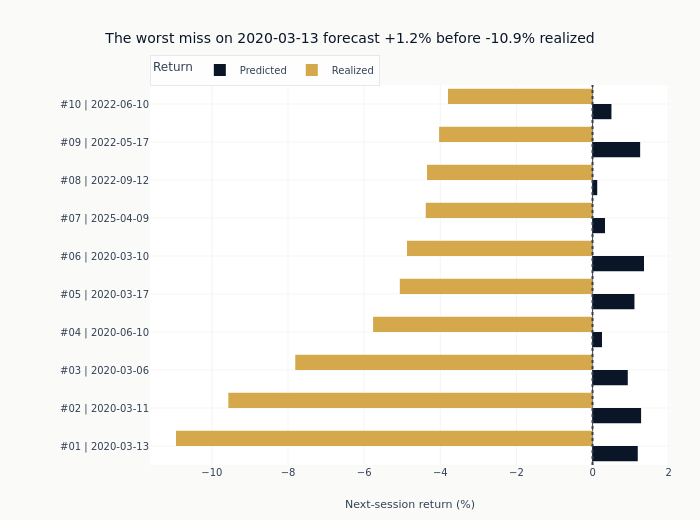

In [21]:
fig = px.bar(
    forecast_long,
    x="return_pct",
    y="trade_label",
    color="series",
    orientation="h",
    barmode="group",
    color_discrete_map={"Predicted": COLORS["blue"], "Realized": COLORS["amber"]},
    category_orders={"trade_label": entry_order},
    title=(
        f"The worst miss on {worst_miss['entry_time']:%Y-%m-%d} forecast "
        f"{worst_miss['predicted_pct']:+.1f}% before {worst_miss['actual_pct']:+.1f}% realized"
    ),
    labels={
        "return_pct": "Next-session return (%)",
        "trade_label": "",
        "series": "Return",
    },
)
fig.add_vline(x=0, line_color=COLORS["neutral"], line_dash="dot")
fig.update_yaxes(automargin=True)
fig.update_layout(
    height=520,
    margin=dict(l=150, r=30, t=85, b=55),
    legend=dict(orientation="h", y=1.08),
)
fig.show()

## 11. Inspect Attribution Variability

Signed SHAP distributions show both direction and trade-to-trade dispersion.
Features are ordered by mean absolute contribution; values are expressed in
basis points of predicted next-session return.

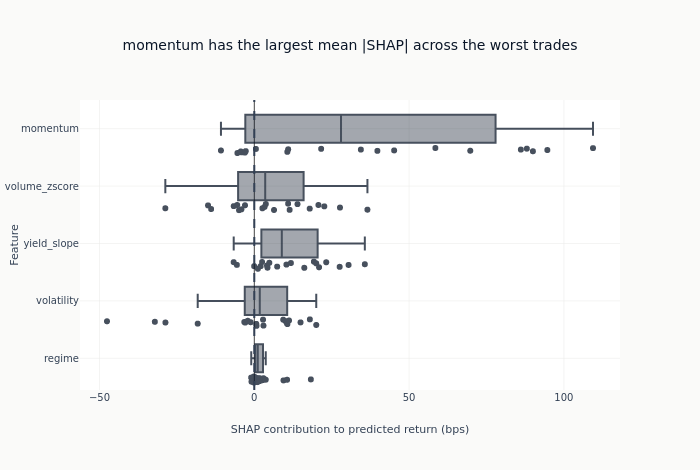

In [22]:
shap_vectors = shap_analyzer.extract_shap_vectors(result.explanations, normalization=None)
mean_abs_shap = np.abs(shap_vectors).mean(axis=0)
feature_order = [FEATURE_COLS[index] for index in np.argsort(mean_abs_shap)[::-1]]
dominant_feature = feature_order[0]

shap_long = pd.DataFrame(shap_vectors, columns=FEATURE_COLS).melt(
    var_name="feature", value_name="shap_value"
)
shap_long["shap_bps"] = shap_long["shap_value"] * 10_000
fig = px.box(
    shap_long,
    x="shap_bps",
    y="feature",
    category_orders={"feature": feature_order},
    points="all",
    title=f"{dominant_feature} has the largest mean |SHAP| across the worst trades",
    labels={"shap_bps": "SHAP contribution to predicted return (bps)", "feature": "Feature"},
)
fig.update_traces(marker_color=COLORS["blue"], line_color=COLORS["blue"], opacity=0.75)
fig.add_vline(x=0, line_color=COLORS["neutral"], line_dash="dash")
fig.update_layout(height=470, showlegend=False)
fig.show()

The forecast gaps confirm that these selected trades are genuine model
failures, not merely low-PnL trades. The signed distributions then show which
features drove each forecast and how unstable those contributions are across
failures. SHAP remains predictive attribution, not a causal explanation.

## Key Takeaways

In [23]:
top_feature_counts = explanation_df.group_by("top_feature").len().sort("len", descending=True)
top_feature_name = top_feature_counts["top_feature"][0]
top_feature_trades = top_feature_counts["len"][0]
cluster_takeaway = (
    f"The default pipeline returns {len(result.error_patterns)} algorithmic hierarchical clusters. "
    "Separation scores and corrected feature tests annotate them rather than gate reporting, and "
    "the characterizer may fall back to top non-significant features. Their composition supports "
    "model-review hypotheses, not causal claims."
    if result.error_patterns
    else "The pipeline returned no error pattern because clustering did not run or failed, not "
    "because a statistical or separation threshold rejected every cluster."
)
display(
    Markdown(
        f"""
1. **Alignment is complete by construction.** Exact next-session timestamps connect all
   {result.n_trades_explained} worst trades to their entry-decision feature vectors, with no
   positional joins or calendar-day guesses.
2. **A fixed {MIN_EXPECTED_RETURN_BPS} bp economic buffer leaves {trades_df.height:,}
   model-directed longs and {losing_trades:,} losses.** It screens economically negligible forecasts;
   the one-session purge keeps training labels outside the later diagnostic boundary.
3. **{top_feature_name} is the largest absolute SHAP contributor for {top_feature_trades} of the
   {len(result.explanations)} explained worst trades.** The box plots show signed dispersion, so
   predictive attribution is not mistaken for a universal failure mechanism.
4. **{cluster_takeaway}**
5. **CUDA execution is best-effort reproducible, not bitwise deterministic.** Fixed seeds and pinned
   inputs do not erase raw prediction drift. Fresh-process evidence therefore reports that drift and
   requires identical buffered trade selections and explanation identities; this campaign does not
   rerun a CPU configuration.
"""
    )
)


1. **Alignment is complete by construction.** Exact next-session timestamps connect all
   20 worst trades to their entry-decision feature vectors, with no
   positional joins or calendar-day guesses.
2. **A fixed 5 bp economic buffer leaves 746
   model-directed longs and 333 losses.** It screens economically negligible forecasts;
   the one-session purge keeps training labels outside the later diagnostic boundary.
3. **momentum is the largest absolute SHAP contributor for 11 of the
   20 explained worst trades.** The box plots show signed dispersion, so
   predictive attribution is not mistaken for a universal failure mechanism.
4. **The default pipeline returns 3 algorithmic hierarchical clusters. Separation scores and corrected feature tests annotate them rather than gate reporting, and the characterizer may fall back to top non-significant features. Their composition supports model-review hypotheses, not causal claims.**
5. **CUDA execution is best-effort reproducible, not bitwise deterministic.** Fixed seeds and pinned
   inputs do not erase raw prediction drift. Fresh-process evidence therefore reports that drift and
   requires identical buffered trade selections and explanation identities; this campaign does not
   rerun a CPU configuration.


**Previous**: `04_factor_exposure` decomposes portfolio-level factor risk and return.

**Next**: `06_stress_testing` extends single-trade diagnostics to portfolio-
level stress scenarios.

**Book reference**: §19.5 (Trade-Level SHAP as Diagnostic Tool).